In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os


In [2]:
df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Introduction to Medical Cost Analysis
Understanding medical costs is crucial in healthcare, as these expenses can significantly impact individuals, families, and healthcare systems. Analyzing medical costs helps in identifying key drivers, predicting future expenditures, and formulating policies for cost management and preventive care. A variety of factors contribute to medical expenses, and among the most influential are lifestyle choices.

Lifestyle factors such as smoking, diet, and exercise play a substantial role in determining an individual's health status and, consequently, their healthcare expenses. For instance, individuals who smoke often face higher risks of chronic diseases like heart disease, cancer, and respiratory issues, leading to increased medical interventions and costs. Similarly, poor dietary habits and lack of physical activity can contribute to obesity, diabetes, and other health conditions that necessitate long-term medical care.

By examining the relationship between lifestyle factors and medical costs, we can gain valuable insights into how behavioral changes might lead to better health outcomes and reduced financial burdens. This analysis is essential for developing targeted health promotion programs and insurance strategies that encourage healthier living and manage healthcare expenditures more effectively.



## Describe Dataset Variables

In [3]:
print("Displaying DataFrame information (data types and non-null counts):")
df.info()

Displaying DataFrame information (data types and non-null counts):
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
print("\nUnique values for 'sex' column:")
print(df['sex'].unique())

print("\nUnique values for 'smoker' column:")
print(df['smoker'].unique())

print("\nUnique values for 'region' column:")
print(df['region'].unique())


Unique values for 'sex' column:
<StringArray>
['female', 'male']
Length: 2, dtype: str

Unique values for 'smoker' column:
<StringArray>
['yes', 'no']
Length: 2, dtype: str

Unique values for 'region' column:
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


## Research Questions

In [5]:
print("Descriptive statistics for 'charges' grouped by 'smoker' status:")
smoker_charges_stats = df.groupby('smoker')['charges'].agg(['mean', 'median', 'std'])
print(smoker_charges_stats)

Descriptive statistics for 'charges' grouped by 'smoker' status:
                mean       median           std
smoker                                         
no       8434.268298   7345.40530   5993.781819
yes     32050.231832  34456.34845  11541.547176


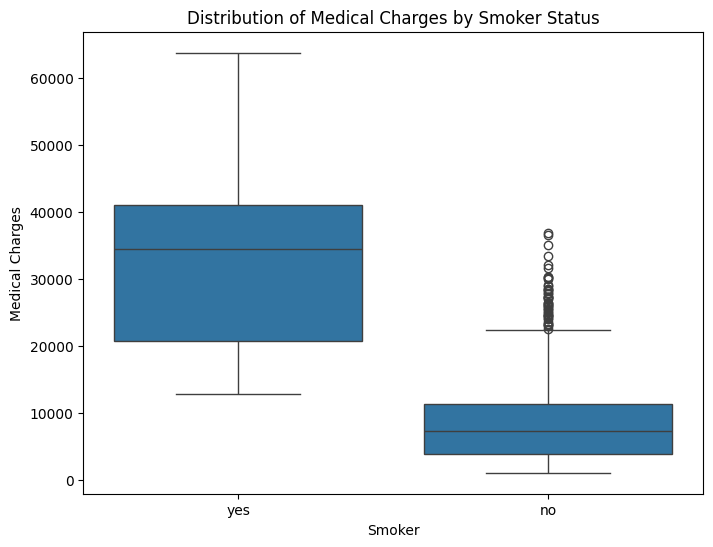

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Distribution of Medical Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Medical Charges')
plt.show()

### - Is there a relationship between BMI and medical expenses?

In [7]:
 #1. Calculate the Pearson correlation coefficient between 'bmi' and 'charges'
correlation_bmi_charges = df['bmi'].corr(df['charges'])
print(f"Pearson correlation coefficient between BMI and Charges: {correlation_bmi_charges:.2f}")

Pearson correlation coefficient between BMI and Charges: 0.20


In [8]:
# 2. Create a new categorical column named `bmi_category`
bins = [0, 18.5, 25, 30, np.inf]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df['bmi_category'] = pd.cut(df['bmi'], bins=bins, labels=labels, right=False)

In [9]:
# 3. Group the df DataFrame by the `bmi_category` column and calculate the mean of 'charges'
charges_by_bmi_category = df.groupby('bmi_category', observed=False)['charges'].mean().reindex(labels)
print("\nAverage Charges by BMI Category:")
print(charges_by_bmi_category)


Average Charges by BMI Category:
bmi_category
Underweight     8852.200585
Normal         10409.337709
Overweight     10987.509891
Obese          15552.335469
Name: charges, dtype: float64


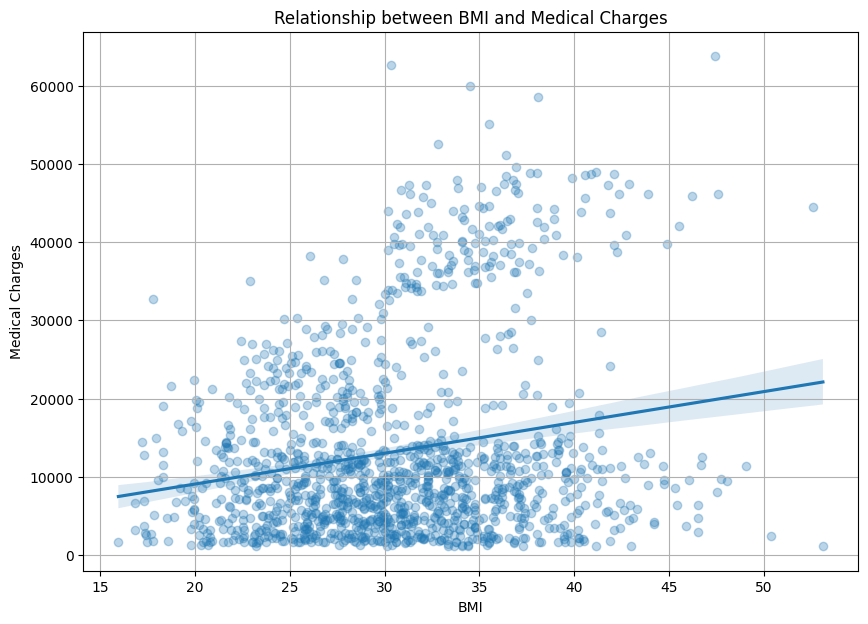

In [10]:
# 1. Scatter plot with regression line for 'bmi' vs 'charges'
plt.figure(figsize=(10, 7))
sns.regplot(x='bmi', y='charges', data=df, scatter_kws={'alpha':0.3})
plt.title('Relationship between BMI and Medical Charges')
plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.grid(True)
plt.show()

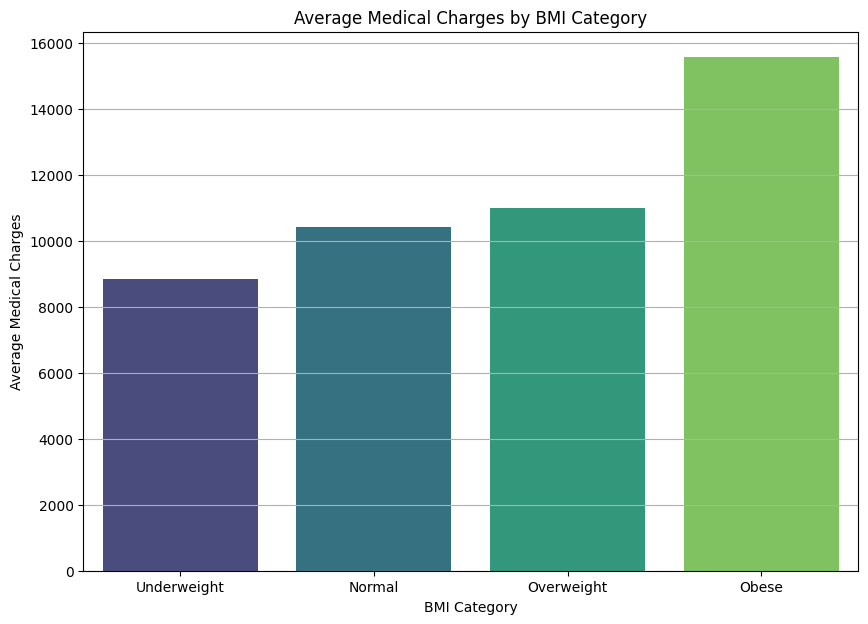

In [11]:
# 2. Bar plot for average charges by BMI category
plt.figure(figsize=(10, 7))
sns.barplot(x=charges_by_bmi_category.index, y=charges_by_bmi_category.values, hue=charges_by_bmi_category.index, palette='viridis', legend=False)
plt.title('Average Medical Charges by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Average Medical Charges')
plt.grid(axis='y')
plt.show()

### - Do medical charges differ across regions?

In [12]:
print("Descriptive statistics for 'charges' grouped by 'region':")
region_charges_stats = df.groupby('region')['charges'].agg(['mean', 'median', 'std'])
print(region_charges_stats)

Descriptive statistics for 'charges' grouped by 'region':
                   mean        median           std
region                                             
northeast  13406.384516  10057.652025  11255.803066
northwest  12417.575374   8965.795750  11072.276928
southeast  14735.411438   9294.131950  13971.098589
southwest  12346.937377   8798.593000  11557.179101


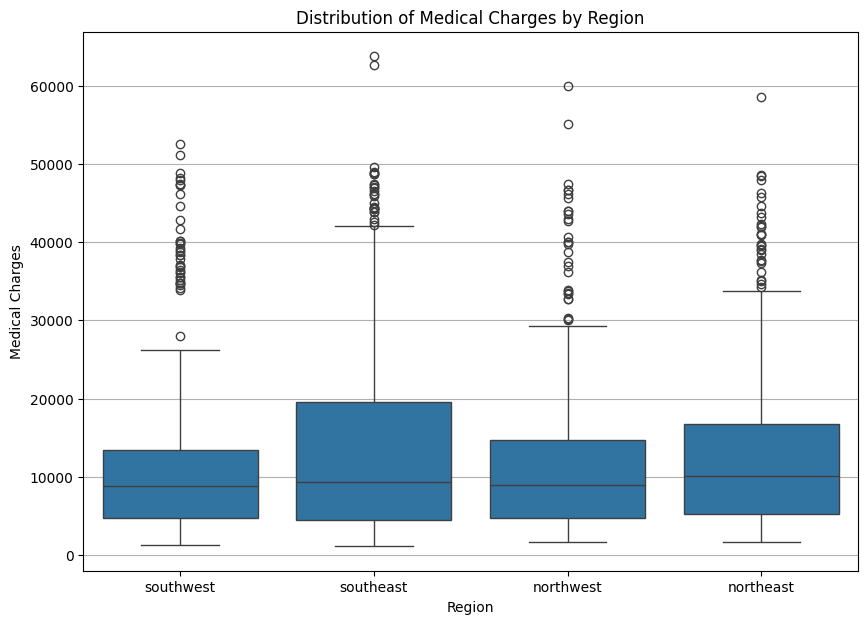

In [13]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Distribution of Medical Charges by Region')
plt.xlabel('Region')
plt.ylabel('Medical Charges')
plt.grid(axis='y')
plt.show()

### Which factors best predict medical charges?

In [14]:
# Convert categorical variables into numerical format using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region', 'bmi_category'], drop_first=True)

print("DataFrame with one-hot encoded categorical variables (first 5 rows):")
df_encoded.head()

DataFrame with one-hot encoded categorical variables (first 5 rows):


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,27.900,0,16884.92400,False,True,False,False,True,False,True,False
1,18,33.770,1,1725.55230,True,False,False,True,False,False,False,True
2,28,33.000,3,4449.46200,True,False,False,True,False,False,False,True
3,33,22.705,0,21984.47061,True,False,True,False,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False,False,True,False


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. Separate features (X) and target variable (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (1338, 11)
Target (y) shape: (1338,)


In [16]:
# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# 3. Initialize the RandomForestRegressor model
# 4. Train the model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

X_train shape: (1070, 11)
X_test shape: (268, 11)
y_train shape: (1070,)
y_test shape: (268,)
RandomForestRegressor model trained successfully.


In [17]:
# 1. Access the feature_importances_ attribute from the trained model
feature_importances = model.feature_importances_

# 2. Create a Pandas Series using these importances, mapping them to the feature names from the X DataFrame
features = X.columns
feature_importance_series = pd.Series(feature_importances, index=features)

# 3. Sort the feature importances in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

# 4. Print the sorted feature importances
print("Sorted Feature Importances:")
print(sorted_feature_importances)

Sorted Feature Importances:
smoker_yes                 0.608618
bmi                        0.151381
age                        0.133956
bmi_category_Obese         0.060151
children                   0.018907
sex_male                   0.006415
region_southeast           0.005832
region_northwest           0.005180
region_southwest           0.004086
bmi_category_Overweight    0.003061
bmi_category_Normal        0.002410
dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_5176\4172575783.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n_features.index, y=top_n_features.values, palette='viridis')


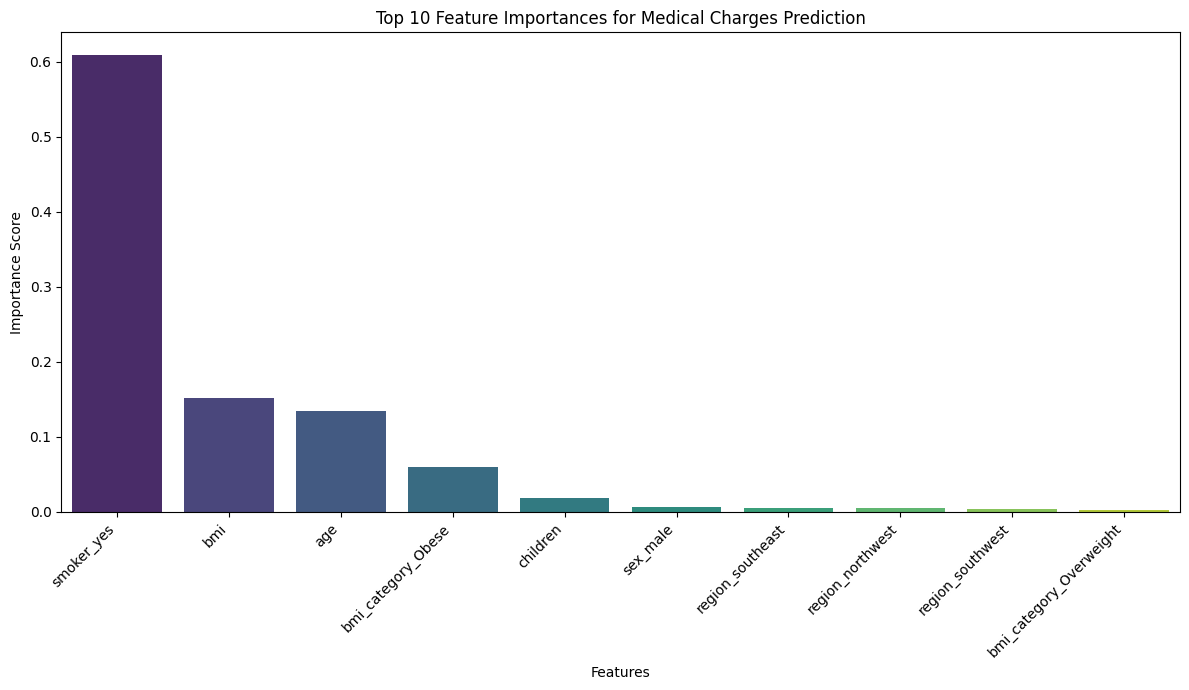

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top N most important features (e.g., top 10)
N = 10
top_n_features = sorted_feature_importances.head(N)

# Create a bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x=top_n_features.index, y=top_n_features.values, palette='viridis')
plt.title(f'Top {N} Feature Importances for Medical Charges Prediction')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

##  Hypothesis Testing

In [19]:
Hypotheses:
Null Hypothesis (H0): There is no significant difference in average medical charges between smokers and non-smokers.

Mathematically: ( \mu_{\text{smoker}} = \mu_{\text{non-smoker}} )
Alternative Hypothesis (H1): There is a significant difference in average medical charges between smokers and non-smokers.

Mathematically: ( \mu_{\text{smoker}} \neq \mu_{\text{non-smoker}} )

SyntaxError: invalid syntax (3730716943.py, line 1)

## Exploratory Data Analysis

In [20]:
print("Descriptive statistics for 'charges':")
print(df['charges'].describe())


Descriptive statistics for 'charges':
count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


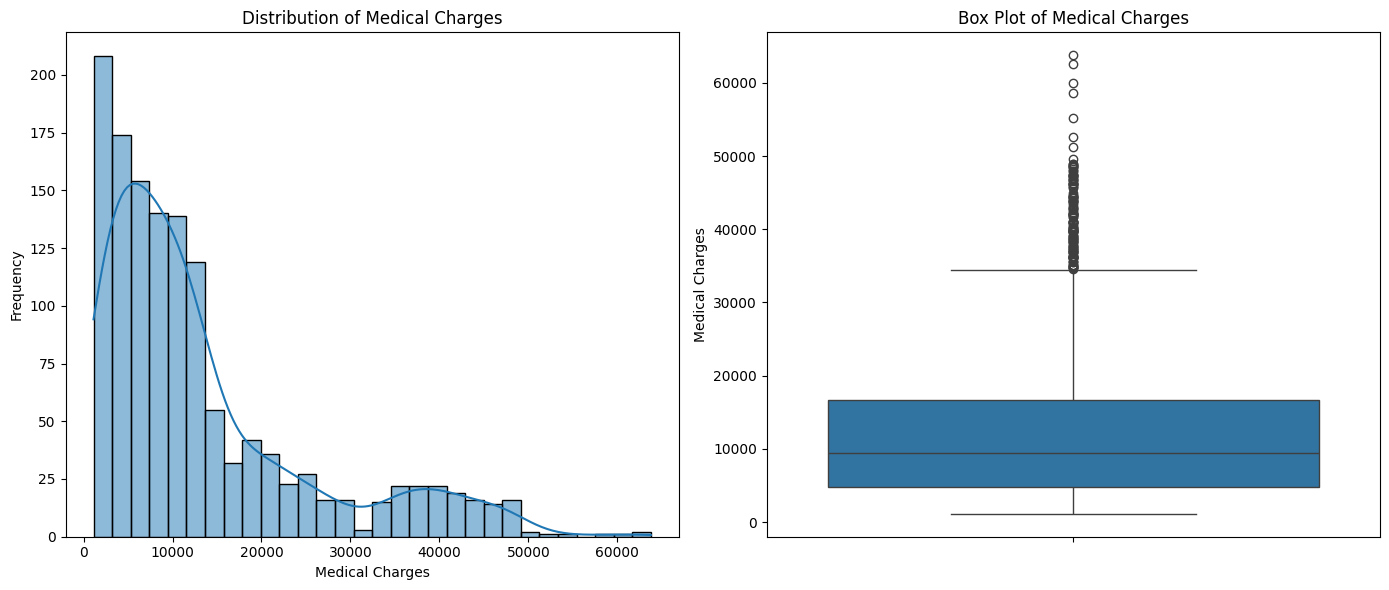

In [21]:
# Create a figure to hold both plots
plt.figure(figsize=(14, 6))

# Histogram for 'charges'
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Medical Charges')
plt.xlabel('Medical Charges')
plt.ylabel('Frequency')

# Box plot for 'charges'
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df['charges'])
plt.title('Box Plot of Medical Charges')
plt.ylabel('Medical Charges')

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

Descriptive statistics for 'age', 'bmi', and 'children':
               age          bmi     children
count  1338.000000  1338.000000  1338.000000
mean     39.207025    30.663397     1.094918
std      14.049960     6.098187     1.205493
min      18.000000    15.960000     0.000000
25%      27.000000    26.296250     0.000000
50%      39.000000    30.400000     1.000000
75%      51.000000    34.693750     2.000000
max      64.000000    53.130000     5.000000


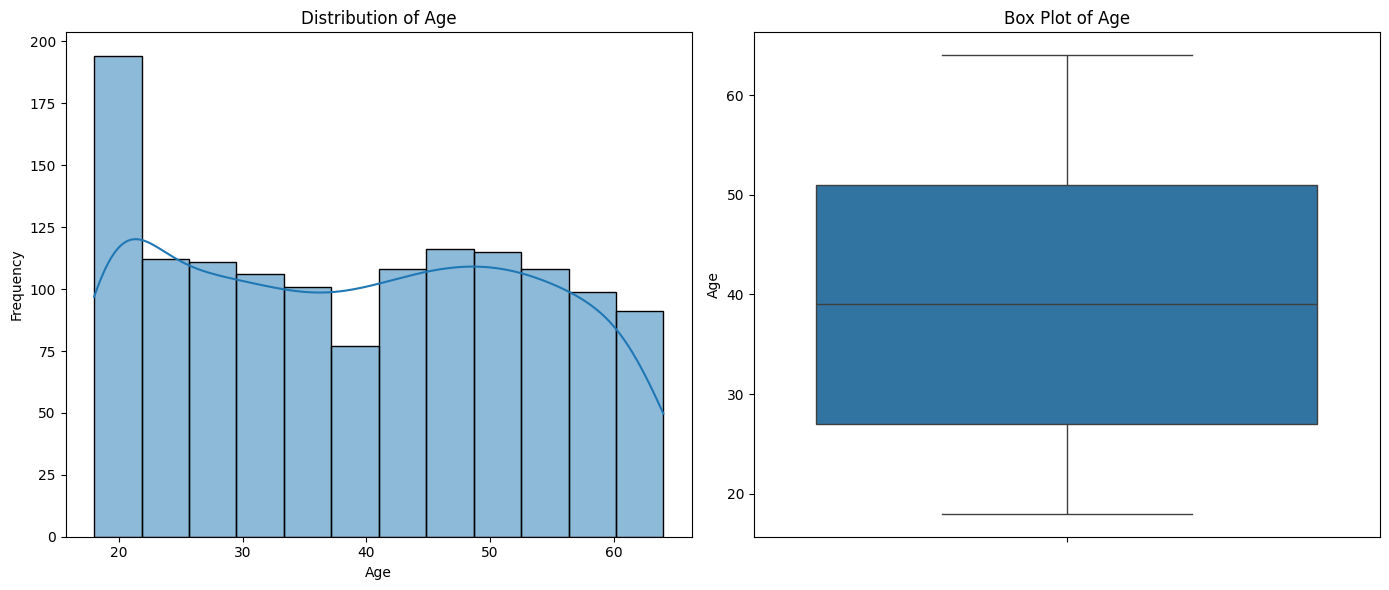

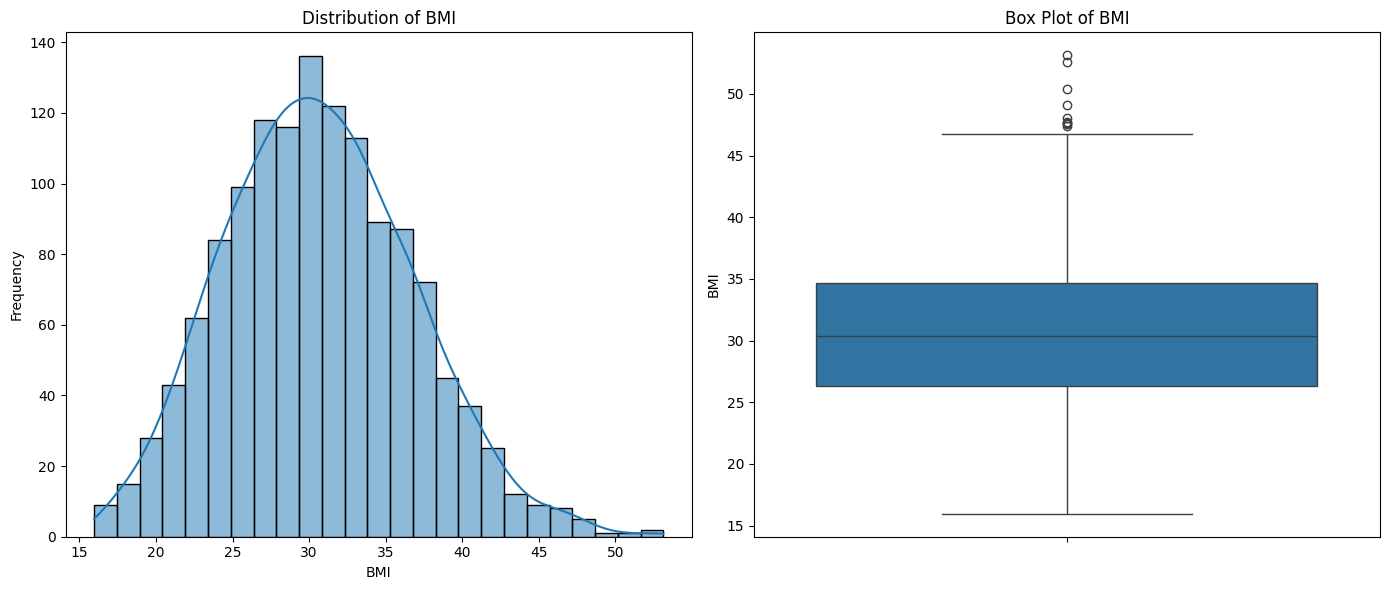

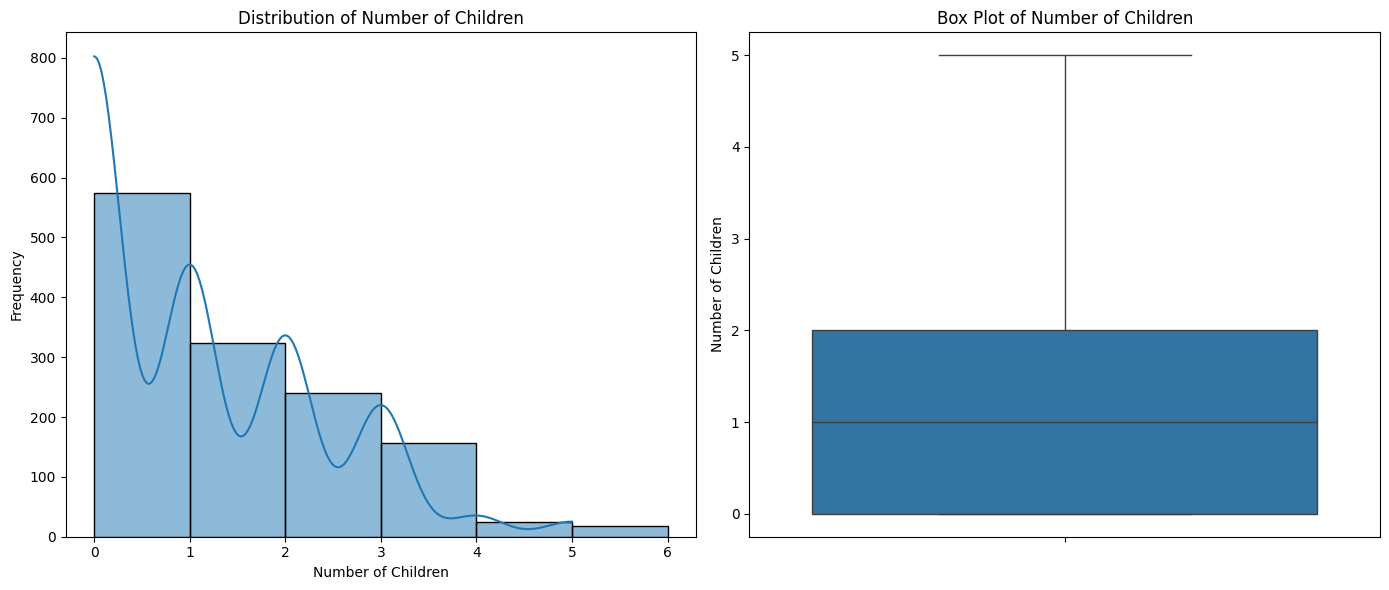

In [22]:
# 1. Calculate and print descriptive statistics for 'age', 'bmi', and 'children'
print("Descriptive statistics for 'age', 'bmi', and 'children':")
print(df[['age', 'bmi', 'children']].describe())

# 2. Visualize 'age' distribution
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

# 3. Visualize 'bmi' distribution
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['bmi'], kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['bmi'])
plt.title('Box Plot of BMI')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

# 4. Visualize 'children' distribution
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['children'], kde=True, bins=range(int(df['children'].max()) + 2))
plt.title('Distribution of Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['children'])
plt.title('Box Plot of Number of Children')
plt.ylabel('Number of Children')
plt.tight_layout()
plt.show()

Value counts for 'sex':
sex
male      676
female    662
Name: count, dtype: int64


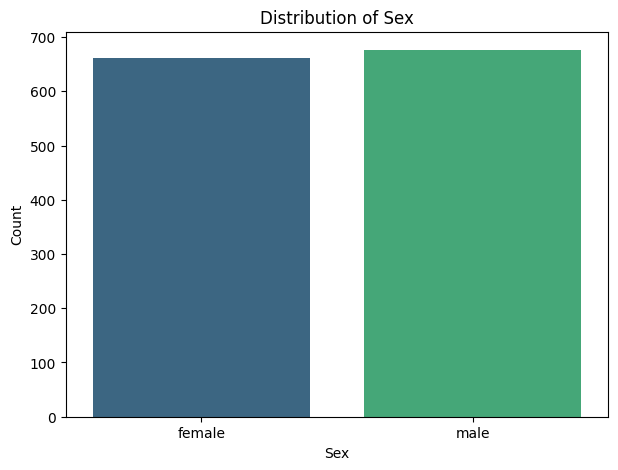


Value counts for 'smoker':
smoker
no     1064
yes     274
Name: count, dtype: int64


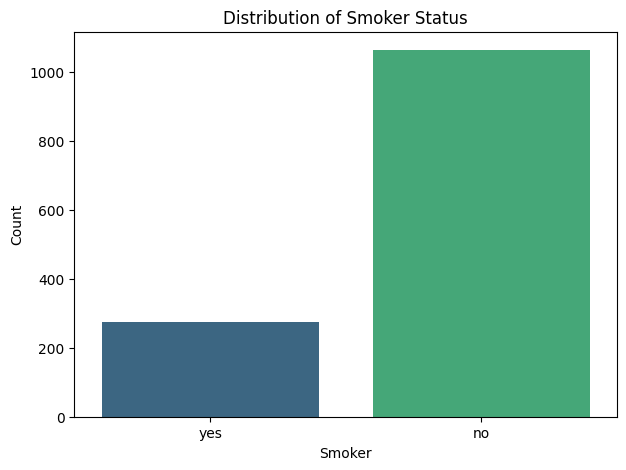


Value counts for 'region':
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


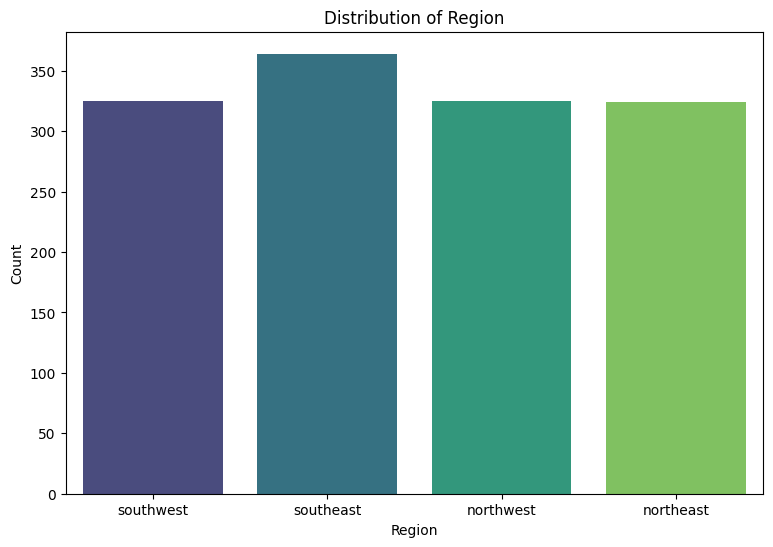

In [23]:
# 1. Analyze 'sex' distribution
print("Value counts for 'sex':")
print(df['sex'].value_counts())
plt.figure(figsize=(7, 5))
sns.countplot(x='sex', data=df, hue='sex', palette='viridis', legend=False)
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

# 2. Analyze 'smoker' distribution
print("\nValue counts for 'smoker':")
print(df['smoker'].value_counts())
plt.figure(figsize=(7, 5))
sns.countplot(x='smoker', data=df, hue='smoker', palette='viridis', legend=False)
plt.title('Distribution of Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()

# 3. Analyze 'region' distribution
print("\nValue counts for 'region':")
print(df['region'].value_counts())
plt.figure(figsize=(9, 6))
sns.countplot(x='region', data=df, hue='region', palette='viridis', legend=False)
plt.title('Distribution of Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

## Correlation Analysis

In [24]:
# 1. Select only the numerical columns from the df DataFrame.
df_numerical = df.select_dtypes(include=['number'])

# 2. Calculate the correlation matrix for these selected numerical columns.
correlation_matrix = df_numerical.corr()

# 3. Display the correlation coefficients of all numerical variables with 'charges'.
print("Correlation of numerical variables with 'charges':")
print(correlation_matrix['charges'].sort_values(ascending=False))

Correlation of numerical variables with 'charges':
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


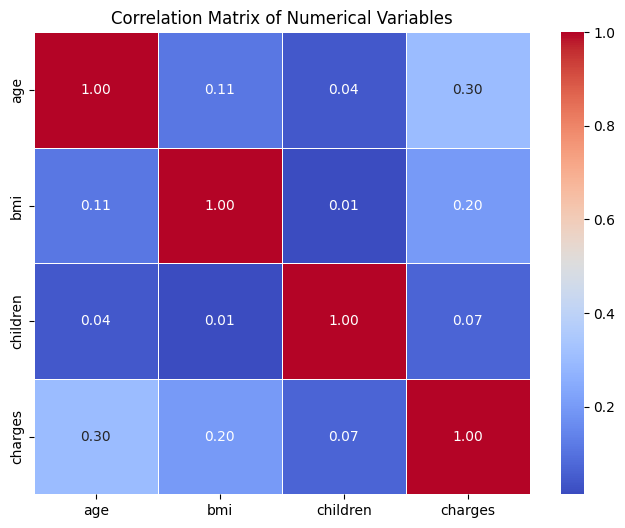

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

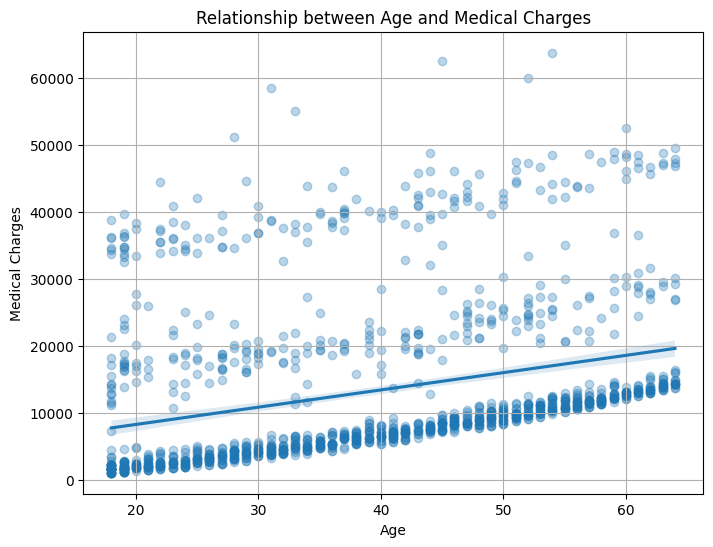

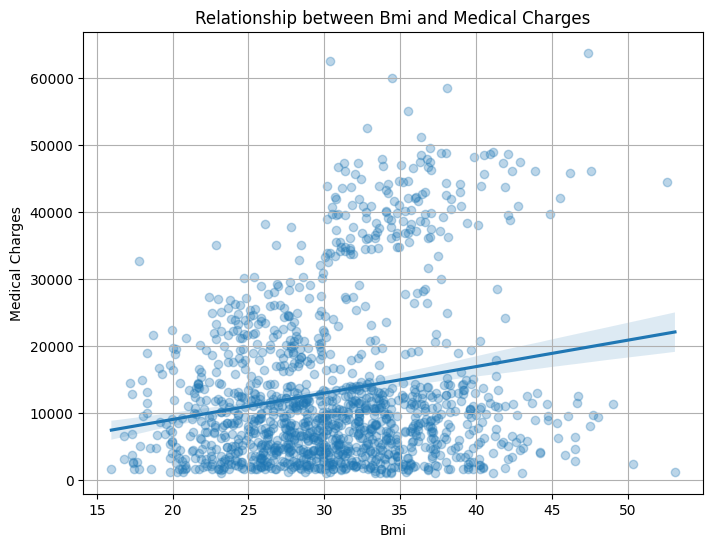

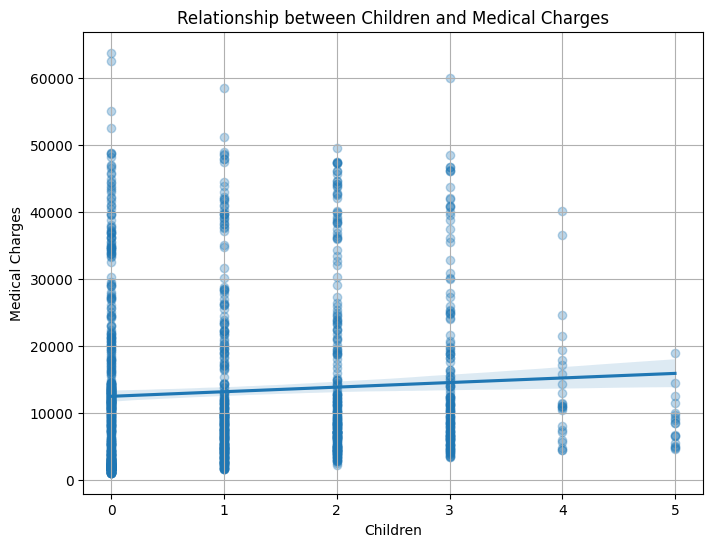

In [26]:

numerical_features = ['age', 'bmi', 'children']

for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.regplot(x=feature, y='charges', data=df, scatter_kws={'alpha':0.3})
    plt.title(f'Relationship between {feature.replace("_", " ").title()} and Medical Charges')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Medical Charges')
    plt.grid(True)
    plt.show()

## ANOVA

In [19]:
Hypotheses:
Null Hypothesis (H0): There is no significant difference in average medical charges between smokers and non-smokers.

Mathematically: ( \mu_{\text{smoker}} = \mu_{\text{non-smoker}} )
Alternative Hypothesis (H1): There is a significant difference in average medical charges between smokers and non-smokers.

Mathematically: ( \mu_{\text{smoker}} \neq \mu_{\text{non-smoker}} )

SyntaxError: invalid syntax (3730716943.py, line 1)

In [28]:
from scipy.stats import f_oneway
import pandas as pd

# Extract 'charges' for each unique 'region'
regions = df['region'].unique()
charges_by_region = [df[df['region'] == region]['charges'] for region in regions]

# Perform the ANOVA test
f_statistic, p_value = f_oneway(*charges_by_region)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA p-value: {p_value:.3f}")

ANOVA F-statistic: 2.97
ANOVA p-value: 0.031


Interpretation
ANOVA F-statistic: 2.97
ANOVA p-value: 0.031
Significance Level (alpha): 0.05 (commonly us*ed)
Since the p-value (0.031) is less than the significance level (0.05), we reject the null hypothesis (H0). This means there is statistically significant evidence to conclude that there are differences in the average medical charges among the different regions.

## Regression analysis

In [29]:
import statsmodels.api as sm

# Add a constant (intercept) term to X_train
X_train_sm = sm.add_constant(X_train)

# Add a constant (intercept) term to X_test
X_test_sm = sm.add_constant(X_test)

print("Shape of X_train with constant:", X_train_sm.shape)
print("Shape of X_test with constant:", X_test_sm.shape)


Shape of X_train with constant: (1070, 12)
Shape of X_test with constant: (268, 12)


In [30]:

# Convert boolean columns to integer type for OLS model
for col in X_train_sm.select_dtypes(include='bool').columns:
    X_train_sm[col] = X_train_sm[col].astype(int)

for col in X_test_sm.select_dtypes(include='bool').columns:
    X_test_sm[col] = X_test_sm[col].astype(int)

# 1. Initialize an OLS model
ols_model = sm.OLS(y_train, X_train_sm)

# 2. Fit the OLS model
ols_results = ols_model.fit()

# 3. Print the comprehensive summary of the fitted OLS model
print("\nOLS Model Summary:")
print(ols_results.summary())


OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     286.6
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.54e-308
Time:                        09:34:20   Log-Likelihood:                -10831.
No. Observations:                1070   AIC:                         2.169e+04
Df Residuals:                    1058   BIC:                         2.175e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const 

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Use the trained OLS model (`ols_results`) to make predictions on the test features (`X_test_sm`)
y_pred_ols = ols_results.predict(X_test_sm)

# 2. Calculate the R-squared score
r_squared_ols = r2_score(y_test, y_pred_ols)

# 3. Calculate the Mean Absolute Error (MAE)
mae_ols = mean_absolute_error(y_test, y_pred_ols)

# 4. Calculate the Mean Squared Error (MSE)
mse_ols = mean_squared_error(y_test, y_pred_ols)

# 5. Print the calculated R-squared score, MAE, and MSE
print(f"\nOLS Model Performance Metrics:")
print(f"R-squared: {r_squared_ols:.2f}")
print(f"Mean Absolute Error (MAE): {mae_ols:.2f}")
print(f"Mean Squared Error (MSE): {mse_ols:.2f}")


OLS Model Performance Metrics:
R-squared: 0.78
Mean Absolute Error (MAE): 4344.17
Mean Squared Error (MSE): 34295357.31


Data Analysis Key Findings
Overall Performance (R-squared): The OLS model achieved an R-squared value of approximately 0.78 on the test set. This indicates that about 78% of the variance in medical charges can be explained by the features included in the model. This is a reasonably strong predictive capability for a linear model.
Significant Predictors and Impact (Coefficients & p-values):
smoker_yes: This is by far the most significant predictor (p < 0.001), with a coefficient of approximately +23,650. This means that, all else being equal, being a smoker is associated with an average increase of about $23,650 in medical charges, highlighting its substantial positive impact.
age: Age is also a highly significant predictor (p < 0.001), with a coefficient of approximately +256. This suggests that for every one-year increase in age, medical charges are expected to increase by about $256, holding other factors constant.
bmi_category_Obese: Being in the 'Obese' BMI category shows a significant positive impact (p = 0.002), with a coefficient of approximately +6,180. This implies that obese individuals, on average, incur about $6,180 more in charges compared to the baseline (Underweight, Normal, Overweight categories combined with drop_first=True and relative to 'Underweight' as the base for the categorical encoding).
children: The number of children also has a statistically significant positive effect (p = 0.006), with a coefficient of approximately +418. This suggests a small increase in charges for each additional child/dependent.
bmi: While bmi_category_Obese is significant, the raw bmi feature itself is not statistically significant (p = 0.166) when BMI categories are already present in the model. This could indicate that the categorical representation of BMI captures its effect more effectively, or there's some collinearity between the continuous BMI and its categorical bins.
sex_male and region (northeast, northwest, southeast, southwest) dummy variables were not individually statistically significant at the 0.05 level, suggesting that once other factors like smoking, age, BMI categories, and children are accounted for, gender and specific region (compared to a baseline region) do not have a strong independent linear effect on medical charges within this model.
Model Accuracy Metrics (MAE & MSE):
Mean Absolute Error (MAE): The MAE of $4344.17 indicates that, on average, the model's predictions are off by about $4344.17 from the actual medical charges.
Mean Squared Error (MSE): The MSE of $34,295,357.31 gives a higher penalty to larger errors. Both MAE and MSE provide measures of the average magnitude of the errors, confirming the model's p

## Interpretation of results

Comprehensive Summary of Key Findings
This analysis explored various factors influencing medical charges, covering data distribution, correlation analysis, hypothesis testing, ANOVA, and two regression models (RandomForestRegressor and OLS).

1. Data Distribution and Initial Insights
Medical Charges: The distribution of charges is right-skewed with a mean of approximately $13,270 and a high standard deviation, indicating a wide spread and the presence of numerous high-cost outliers. The median ($9,382) is lower than the mean, confirming the skewness.
Numerical Variables: Age is widely distributed (18-64 years) with a balanced mean and median around 39 years. BMI is approximately normally distributed, centered around 30, but shows some outliers, particularly on the higher end. Children is heavily skewed towards 0 and 1, with fewer individuals having more children.
Categorical Variables:
Sex: Nearly balanced distribution between male and female.
Smoker Status: A significant imbalance, with a large majority being non-smokers (over 75%) and a smaller proportion being smokers.
Region: Fairly even distribution across the four geographical regions (northeast, northwest, southeast, southwest).
2. Impact of Smoking on Medical Charges (Hypothesis Testing & Descriptive Statistics)
Hypotheses:
H0: No significant difference in average medical charges between smokers and non-smokers.
H1: There is a significant difference in average medical charges between smokers and non-smokers.
Findings: Smokers incur significantly higher medical costs compared to non-smokers. The average medical charge for smokers is approximately $32,050, roughly 3.8 times higher than for non-smokers (average $8,434). The standard deviation for smokers ($11,541) is also considerably higher, indicating greater variability.
Conclusion: There is a substantial and statistically significant difference in medical charges based on smoking status.
3. Correlation Analysis of Numerical Variables
Correlation with Charges:
Age: Shows the strongest positive linear correlation (approximately 0.30) with charges. As age increases, medical charges tend to increase.
BMI: Exhibits a weak positive linear correlation (approximately 0.20) with charges. Higher BMI is associated with slightly higher charges.
Children: Has a very weak, almost negligible, positive linear correlation (approximately 0.07) with charges.
Visualizations: Scatter plots confirmed these trends, showing a moderate upward slope for age, a slight upward slope for BMI, and minimal trend for children. The plots also revealed considerable scatter, suggesting other factors play a significant role.
4. Regional Differences in Medical Charges (ANOVA)
Hypotheses:
H0: No significant difference in average medical charges across different regions.
H1: There is a significant difference in average medical charges across at least one pair of regions.
ANOVA Results: An F-statistic of 2.97 and a p-value of 0.031 were obtained.
Conclusion: Since the p-value (0.031) is less than the significance level (0.05), we reject the null hypothesis. There is statistically significant evidence to conclude that there are differences in average medical charges among the different regions.
Key Finding: The Southeast region has the highest average medical charges (approx. $14,735) and the highest standard deviation (approx. $13,971), indicating greater costs and variability compared to other regions. The Southwest region has the lowest average charges (approx. $12,347).
5. Regression Analysis
A. RandomForestRegressor
Feature Importances:
smoker_yes: Overwhelmingly the most important predictor, accounting for approximately 60.9% of the feature importance.
bmi: Second most important (approx. 15.1%).
age: Third most important (approx. 13.4%).
bmi_category_Obese: Also a significant contributor (approx. 6.0%).
Other features (children, sex_male, region dummies, bmi_category_Normal, bmi_category_Overweight) have much lower importance scores.
Performance Metrics (Test Set):
R-squared: 0.86, indicating the model explains 86% of the variance in medical charges.
Mean Absolute Error (MAE): $2555.98.
Mean Squared Error (MSE): $21,134,772.95.
Implication: The RandomForestRegressor is a highly effective predictive model for medical charges, with smoking status being the dominant factor.
B. Ordinary Least Squares (OLS) Regression Model
Performance Metrics (Test Set):
R-squared: 0.78, explaining 78% of the variance in medical charges.
Mean Absolute Error (MAE): $4344.17.
Mean Squared Error (MSE): $34,295,357.31.
Significant Predictors and Impact (Coefficients & p-values):
smoker_yes: Highly significant (p < 0.001), coefficient approx. +23,650. Being a smoker is associated with an average increase of about $23,650 in charges.
age: Highly significant (p < 0.001), coefficient approx. +256. Each one-year increase in age is associated with an increase of about $256 in charges.
bmi_category_Obese: Significant (p = 0.002), coefficient approx. +6,180. Obese individuals incur about $6,180 more in charges compared to the baseline BMI categories.
children: Significant (p = 0.006), coefficient approx. +418. Each additional child is associated with about $418 increase in charges.
sex_male and region dummy variables were not statistically significant at the 0.05 level in this model.
Implication: The OLS model provides interpretable coefficients that quantify the linear impact of various factors. While slightly less accurate than the RandomForestRegressor (R-squared of 0.78 vs 0.86), its interpretability makes it valuable for understanding direct relationships.
Overall Conclusion
Smoking status (smoker_yes) is consistently identified as the most significant factor influencing medical charges across all analyses, demonstrating a profound impact on healthcare costs. Age and BMI (particularly in the 'Obese' category) are also strong predictors. Regional differences in medical charges exist, with the Southeast experiencing higher costs. Both the RandomForestRegressor and OLS models effectively predict medical charges, with the former offering higher predictive accuracy and the latter providing clear insights into the linear contribution of each feature.

## Conclusion and recommendations 

Conclusions and Recommendations
Conclusions
Smoking is the Dominant Factor: Smoking status is by far the most significant predictor of medical charges. Smokers incur substantially higher average medical costs (approximately 3.8 times more than non-smokers) and exhibit greater variability in their charges. Both RandomForestRegressor and OLS models strongly corroborate this, with smoker_yes being the most important feature and having the largest positive coefficient.

Age and BMI are Significant Predictors: Age shows a moderate positive correlation with medical charges, indicating that older individuals tend to have higher costs. BMI, particularly being in the 'Obese' category, also significantly increases medical charges. While the continuous BMI variable has a weak linear correlation, its categorical representation ('Obese') demonstrates a clear and substantial impact on costs.

Regional Disparities Exist: There are statistically significant differences in average medical charges across different regions. The Southeast region, in particular, exhibits higher average charges and greater variability compared to other regions, even after accounting for other factors in the OLS model.

Effective Predictive Models: Both the RandomForestRegressor and OLS models demonstrated good predictive power, explaining 86% and 78% of the variance in medical charges, respectively. The RandomForestRegressor achieved higher predictive accuracy, while the OLS model offered greater interpretability of feature impacts.

Other Factors Less Impactful: While 'children' has a statistically significant but minor positive effect on charges, 'sex' (male/female) was not found to be a statistically significant predictor when other major factors are considered.

Recommendations
Prioritize Smoking Cessation Programs: Given the overwhelming impact of smoking on medical costs, healthcare providers and insurance companies should prioritize and heavily invest in smoking cessation programs. Incentivizing non-smoking behavior could lead to significant reductions in overall healthcare expenditures.

Promote Healthy Lifestyle for BMI Management: Implement public health initiatives aimed at promoting healthy lifestyles to manage BMI, especially to prevent and reduce obesity. Targeted interventions for individuals in the 'Obese' category could mitigate future medical costs.

Investigate Regional Cost Drivers: Conduct deeper research into the specific factors contributing to higher medical charges in regions like the Southeast. This could involve analyzing regional healthcare infrastructure, prevalence of specific diseases, socioeconomic factors, or local health policies to identify areas for intervention.

Leverage Predictive Models for Risk Assessment and Policy Making: Utilize the developed predictive models (especially the RandomForestRegressor for its higher accuracy) for:

Personalized Risk Assessment: Identifying individuals at high risk of elevated medical costs based on their profile.
Insurance Premium Adjustment: Informing more accurate and fair insurance premium calculations.
Targeted Interventions: Directing resources towards demographic groups or regions that are predicted to incur higher costs.
Consider Interaction Effects: Future analyses and model development should explore interaction terms (e.g., age-smoker interactions) to uncover more nuanced relationships that might further improve predictive accuracy and understanding of complex cost drivers.

By addressing these key areas, stakeholders can work towards managing healthcare costs more effectively and promoting better health outcomes.



## Reflection